In [2]:
import pandas as pd
data=pd.read_csv('Unit_price_cleaned.csv')
data = data.drop('Unnamed: 0', axis=1)

In [3]:
print(data['Total Sale'].value_counts(dropna=False).to_string())

Total Sale
NaN            414
6665108.4        1
459478.11        1
6329990.01       1
3853718.91       1
933143.96        1
5385913.83       1
7134012.27       1
8635891.44       1
717097.72        1
12248503.26      1
480544.4         1
1079899.16       1
13861863.36      1
16028191.4       1
5769991.73       1
230559.64        1
1507949.4        1
2693170.96       1
12849738.39      1
19212038.66      1
17520575.55      1
1008749.04       1
26075188.41      1
10607068.55      1
7357073.14       1
3283350.4        1
06-02-2025       1
2/28/2024        1
05-02-2025       1
11-10-2023       1
1/13/2025        1
01-12-2025       1
6/30/2025        1
168824.4         1
2001571.65       1
62817            1
3090320.2        1
15747809         1
291699.66        1
4845673.84       1
yyu              1
1773892.88       1
326782.96        1
15691749.92      1
10342017.16      1
2278801.28       1
16506303.68      1
21572015         1
4843200.23       1
5687906.97       1
3170553.62       1
t

In [4]:

data['Total Sale']=pd.to_numeric(data['Total Sale'],errors='coerce')
print(data['Total Sale'].describe())

count    1.350000e+02
mean     7.096978e+06
std      6.359815e+06
min      5.788704e+04
25%      1.894987e+06
50%      5.049848e+06
75%      1.141446e+07
max      2.873459e+07
Name: Total Sale, dtype: float64


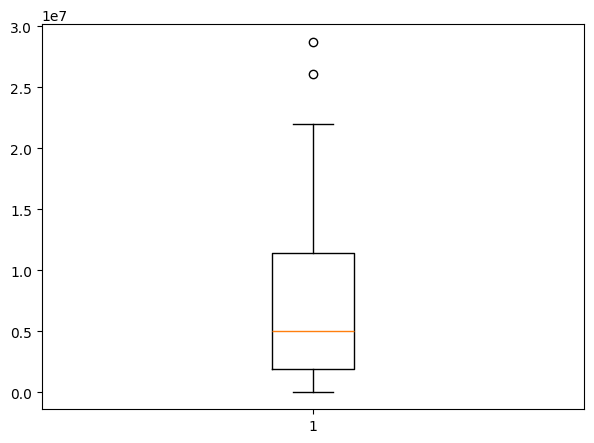

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.boxplot(data['Total Sale'].dropna())
plt.show()

In [6]:
data['Total Sale']=data['Total Sale'].fillna(data['Unit Price'] * data['Units Sold'])

In [7]:
Q1=data['Total Sale'].quantile(0.25)
Q3=data['Total Sale'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=data[(data['Total Sale']<lower)| (data['Total Sale']>upper)]
print(outliers.to_string())

     Customer Name  State Product  Units Sold  Unit Price   Total Sale   Sale Date Sales Channel                              Order ID
84     megan young  Abuja   Phone          93   280378.37  26075188.41  03-03-2024        Direct  23dfecd7-0e73-4dd7-86ac-1b04dd1d6cd1
176   Unknown Name   Kano  Tablet         100   215720.15  21572015.00  10/30/2023           NaN                                   NaN
453    lisa hunter   Osun   Phone          74   297101.90  21985540.60  09-04-2024        Retail  6fff15cc-b2dc-4c34-8f67-448e10eceb1f
517  veronica king  Delta   Phone          98   293210.10  28734589.80   7/15/2024        Online  21761930-f6d7-4248-a995-ecc36f5b09a6


In [8]:
print(data['Total Sale'].value_counts(dropna=False).to_string())

Total Sale
7617016.80     45
13012403.70     3
5673115.20      2
7458328.95      2
6680449.92      1
816885.02       1
5956651.68      1
4383543.85      1
7643162.40      1
5607912.48      1
1443200.55      1
4374205.88      1
1160716.32      1
6490135.20      1
5358610.08      1
8850756.20      1
11947544.64     1
3689817.60      1
764890.56       1
3263553.12      1
3488158.56      1
4201847.52      1
1444865.50      1
4335196.80      1
5893133.76      1
10034129.76     1
3808508.40      1
7563681.12      1
5503478.88      1
9272311.68      1
4975307.52      1
698005.92       1
3005590.86      1
12352012.80     1
6723274.56      1
12715304.64     1
5194250.88      1
6872562.78      1
19089619.92     1
6726816.48      1
4093259.04      1
4647537.60      1
3464621.76      1
5725982.40      1
10141377.12     1
3550281.19      1
15639384.69     1
10868258.88     1
2543636.90      1
19363748.34     1
2755780.80      1
3068948.64      1
2181950.00      1
4382630.88      1
13063503.84     1

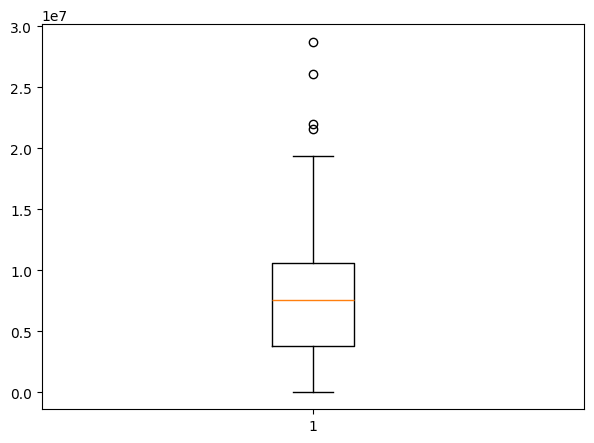

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.boxplot(data['Total Sale'].dropna())
plt.show()

In [10]:
Q1=data['Total Sale'].quantile(0.25)
Q3=data['Total Sale'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=data[(data['Total Sale']<lower)| (data['Total Sale']>upper)]
print(outliers.to_string())

     Customer Name  State Product  Units Sold  Unit Price   Total Sale   Sale Date Sales Channel                              Order ID
84     megan young  Abuja   Phone          93   280378.37  26075188.41  03-03-2024        Direct  23dfecd7-0e73-4dd7-86ac-1b04dd1d6cd1
176   Unknown Name   Kano  Tablet         100   215720.15  21572015.00  10/30/2023           NaN                                   NaN
453    lisa hunter   Osun   Phone          74   297101.90  21985540.60  09-04-2024        Retail  6fff15cc-b2dc-4c34-8f67-448e10eceb1f
517  veronica king  Delta   Phone          98   293210.10  28734589.80   7/15/2024        Online  21761930-f6d7-4248-a995-ecc36f5b09a6


In [11]:
med=data['Total Sale'].median()
wrong_vall=[26075188.41,21572015.00,21985540.60,28734589.80]
data['Total Sale']=data['Total Sale'].replace(wrong_vall,med)

In [12]:
import numpy as np

data[np.isclose(data['Total Sale'], 7617016.80)]

,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,Unknown Name,Rivers,Keyboard,48,158687.85,7617016.8,4/27/2025,Online,NaN
11,monica herrera,Niger,Keyboard,48,158687.85,7617016.8,2/28/2024,Direct,4b86b5a1-ca6f-4ff8-964c-fbd2bc92fd81
31,zachary hicks,Sokoto,Phone,48,158687.85,7617016.8,7/31/2023,Wholesale,7a6a2107-2231-4050-b515-94943818cfd3
41,cassandra gaines,Osun,Monitor,48,158687.85,7617016.8,5/27/2025,Retail,33c08bf1-8167-499f-a723-ada38c32bdb2
51,shane henderson,Borno,Charger,48,158687.85,7617016.8,2/27/2025,Online,41241bb4-655c-4508-8592-bfa5b928e23f
61,timothy duncan,Delta,Headphones,48,158687.85,7617016.8,07-06-2024,Wholesale,e42e707a-fe2b-4987-9fdc-abbf6b9cd71c
71,amber kidd,Anambra,Charger,48,158687.85,7617016.8,10-09-2024,Retail,NaN
81,amy silva,Imo,Camera,48,158687.85,7617016.8,10/15/2023,Wholesale,3ea6e5b2-0c76-4d28-9f49-5037b40a9181
84,megan young,Abuja,Phone,93,280378.37,7617016.8,03-03-2024,Direct,23dfecd7-0e73-4dd7-86ac-1b04dd1d6cd1
91,Unknown Name,Enugu,Keyboard,48,158687.85,7617016.8,04-04-2024,NaN,69df14e9-3896-41dd-8570-b59fa903ae67


In [13]:
data[(data['Unit Price'] * data['Units Sold'] == data['Total Sale'])].value_counts()

Customer Name     State    Product   Units Sold  Unit Price  Total Sale   Sale Date   Sales Channel  Order ID                            
zachary mitchell  Sokoto   Keyboard  65          206948.51   13451653.15  12-02-2023  Online         ec93e596-2b01-4723-8cf6-97a57603c36c    1
trevor johnson    Katsina  Keyboard  26          55571.75    1444865.50   8/21/2024   Wholesale      0f2d5c15-eb34-4d3a-a95e-5ea9c9230c64    1
tracy montoya     Plateau  Keyboard  48          72670.17    3488168.16   8/19/2023   Online         ddb449dc-7710-4966-a082-7f7611a529b4    1
tracy house       Kano     Monitor   61          287222.55   17520575.55  11/29/2023  Retail         6118433b-882c-4d1e-ac93-a7918b60c511    1
tracy burke       Delta    Keyboard  48          226422.06   10868258.88  3/19/2024   Retail         84fa4c72-39e7-44f1-97fb-613a21f89d06    1
                                                                                                                                            ..
Unknown Name      Bauchi   Tablet    48          282220.37   13546577.76  03-09-2024  Direct         176de21f-1b46-4bdc-9c56-d9bc5111d31d    1
                           Phone     48          297857.61   14297165.28  08-09-2024  Direct         bd90b81a-fbe0-46b8-ae0f-65a82a131c1f    1
                           Keyboard  56          280209.82   15691749.92  7/31/2024   Retail         2f1dc121-7d02-4c6d-8bea-75c1b86677aa    1
                  Anambra  Tablet    48          41678.71    2000578.08   2/21/2024   Wholesale      8468b74d-85e3-4de5-98c1-aad6f3f8dea4    1
                           Monitor   48          81704.25    3921804.00   11-07-2024  Wholesale      69a53b4f-8ff8-469d-8ec0-713dea2c7a51    1
Name: count, Length: 385, dtype: int64

In [15]:
print(data['Total Sale'])

0       7617016.80
1      12863661.12
2       2033491.68
3      13413357.12
4       4603187.52
          ...     
553      143934.54
554    10740683.52
555     4996076.16
556     1428330.72
557     3361302.24
Name: Total Sale, Length: 558, dtype: float64


In [16]:
from google.colab import files
data.to_csv('total_sale_cleaned.csv')
files.download('total_sale_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>